# ML Algorithms — Core Implementations

Hands-on implementation of 5 foundational ML algorithms:
**Linear Regression · Logistic Regression · Decision Tree · Random Forest · K-Means**

Each section: load data → train → predict → evaluate → interpret.
Uses `scikit-learn` on built-in datasets so everything here runs standalone.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, silhouette_score
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (7, 5)
print("Libraries loaded.")

Libraries loaded.


## 1. Linear Regression

**Task:** Predict a continuous value (disease progression score, one year post-baseline) from numeric features.
**Dataset:** Diabetes dataset (bundled with sklearn, no download needed).

In [ ]:
diabetes = load_diabetes(as_frame=True)
X_lr = diabetes.data
y_lr = diabetes.target

print(X_lr.shape)
X_lr.head()

(442, 10)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

scaler_lr = StandardScaler()
X_train_s = scaler_lr.fit_transform(X_train)
X_test_s = scaler_lr.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_s, y_train)

y_pred = lin_reg.predict(X_test_s)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2 :", r2_score(y_test, y_pred))

MAE : 42.79409467959994
MSE : 2900.193628493482
RMSE: 53.85344583676593
R^2 : 0.4526027629719195


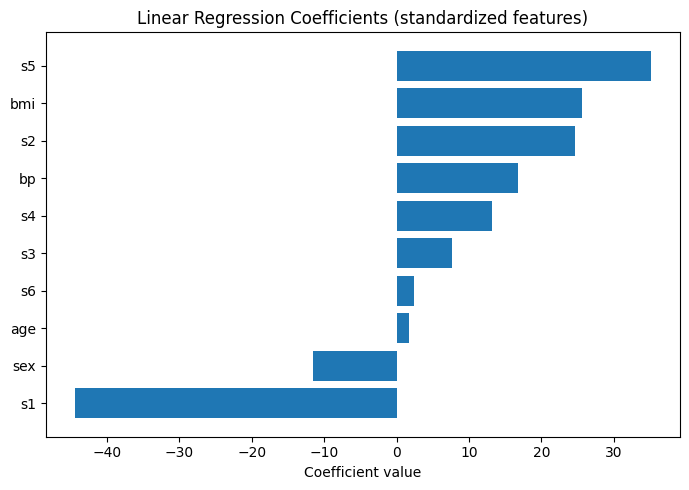

In [ ]:
coef_df = pd.DataFrame({'feature': X_lr.columns, 'coefficient': lin_reg.coef_}).sort_values('coefficient')
plt.barh(coef_df['feature'], coef_df['coefficient'])
plt.title('Linear Regression Coefficients (standardized features)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

**Interpretation:** Coefficients show each standardized feature's effect on predicted value, holding others constant. R² tells us the fraction of variance in house value explained by the model.

## 2. Logistic Regression

**Task:** Binary classification — malignant vs. benign tumor.
**Dataset:** Breast Cancer Wisconsin (built into sklearn).

In [ ]:
cancer = load_breast_cancer(as_frame=True)
X_clf = cancer.data
y_clf = cancer.target  # 0 = malignant, 1 = benign

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_s = scaler_clf.fit_transform(X_train)
X_test_s = scaler_clf.transform(X_test)

log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_s, y_train)

y_pred = log_reg.predict(X_test_s)
y_proba = log_reg.predict_proba(X_test_s)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1       : 0.9861111111111112


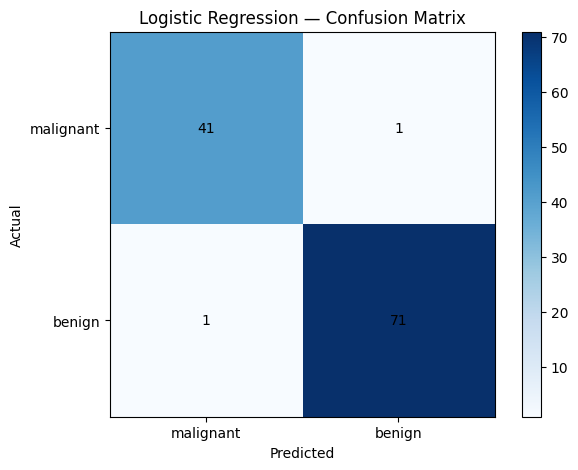

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.xticks([0, 1], ['malignant', 'benign'])
plt.yticks([0, 1], ['malignant', 'benign'])
plt.colorbar()
plt.show()

print(classification_report(y_test, y_pred, target_names=cancer.target_names))

**Interpretation:** Logistic Regression outputs a probability via the sigmoid function; we threshold at 0.5 to get a class. Precision/recall matter more than raw accuracy here since misclassifying malignant as benign is costly.

## 3. Decision Tree

**Task:** Same breast cancer classification, using a Decision Tree for an interpretable, non-linear model.
**Note:** Trees don't need feature scaling, so raw features are used.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

Accuracy : 0.9385964912280702
Precision: 0.9577464788732394
Recall   : 0.9444444444444444
F1       : 0.951048951048951


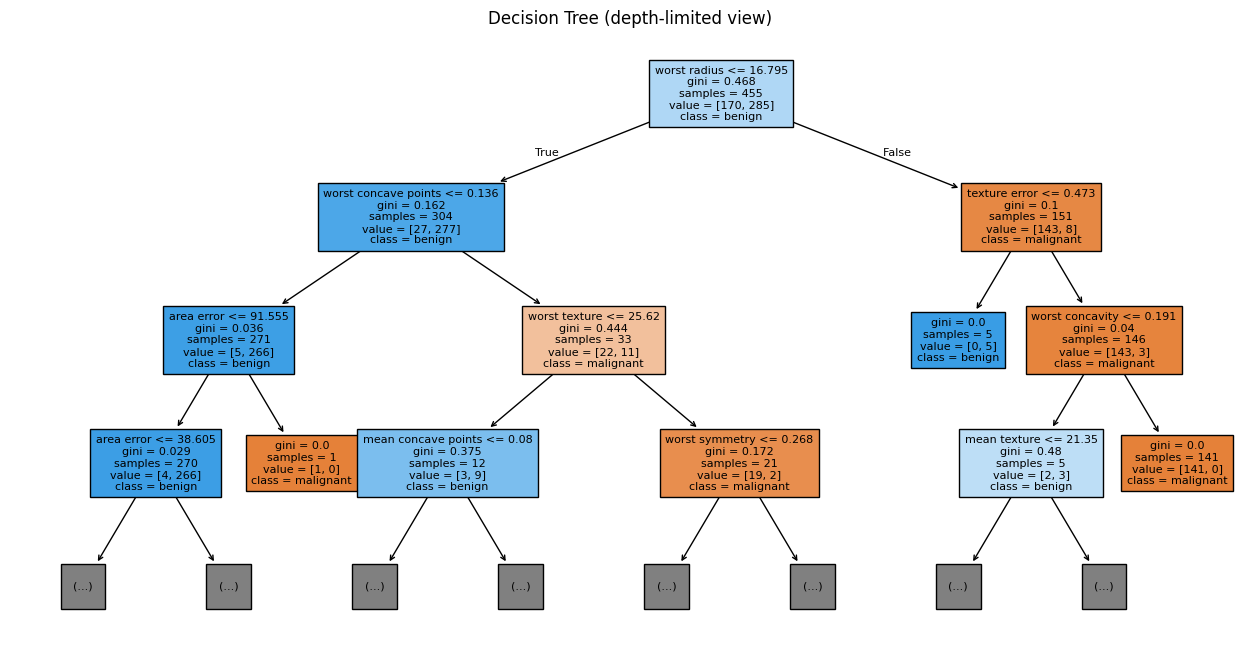

In [ ]:
plt.figure(figsize=(16, 8))
plot_tree(dt, feature_names=cancer.feature_names, class_names=cancer.target_names,
          filled=True, max_depth=3, fontsize=8)
plt.title('Decision Tree (depth-limited view)')
plt.show()

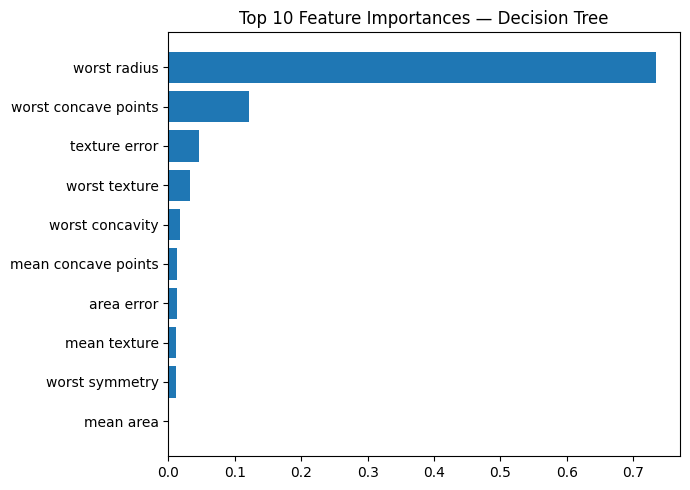

In [ ]:
importances = pd.DataFrame({
    'feature': cancer.feature_names,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.barh(importances['feature'][::-1], importances['importance'][::-1])
plt.title('Top 10 Feature Importances — Decision Tree')
plt.tight_layout()
plt.show()

**Interpretation:** `max_depth=4` caps complexity to reduce overfitting. Feature importance shows which measurements the tree splits on most, giving a built-in explanation of its decisions.

## 4. Random Forest

**Task:** Same dataset, using an ensemble of trees (bagging) to reduce variance and improve generalization over a single Decision Tree.

In [ ]:
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1       :", f1_score(y_test, y_pred))

Accuracy : 0.9473684210526315
Precision: 0.9583333333333334
Recall   : 0.9583333333333334
F1       : 0.9583333333333334


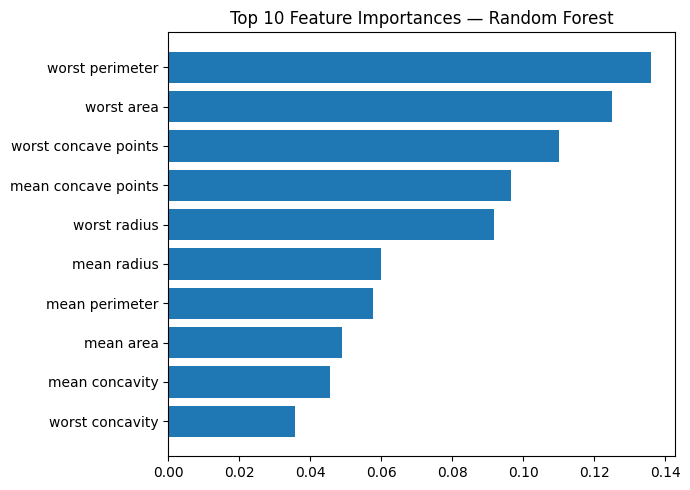

In [ ]:
importances_rf = pd.DataFrame({
    'feature': cancer.feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.barh(importances_rf['feature'][::-1], importances_rf['importance'][::-1])
plt.title('Top 10 Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
print(f"{'Model':<20}{'Accuracy':<12}{'F1 Score':<12}")
print(f"{'Decision Tree':<20}{accuracy_score(y_test, dt.predict(X_test)):<12.4f}{f1_score(y_test, dt.predict(X_test)):<12.4f}")
print(f"{'Random Forest':<20}{accuracy_score(y_test, rf.predict(X_test)):<12.4f}{f1_score(y_test, rf.predict(X_test)):<12.4f}")

Model               Accuracy    F1 Score    
Decision Tree       0.9386      0.9510      
Random Forest       0.9474      0.9583      


**Interpretation:** Random Forest averages many decorrelated trees (each trained on a bootstrap sample with random feature subsets), which usually gives more stable, better-generalizing predictions than a single tree — visible here in the accuracy/F1 comparison.

## 5. K-Means Clustering

**Task:** Unsupervised clustering — group Iris flowers by feature similarity, no labels used during training.
**Dataset:** Iris (built into sklearn).

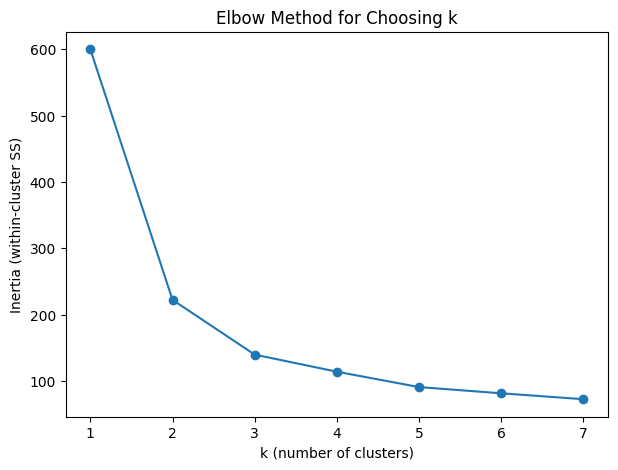

In [ ]:
iris = load_iris(as_frame=True)
X_km = iris.data
y_true = iris.target  # only used afterward to *evaluate* cluster quality, not for training

scaler_km = StandardScaler()
X_km_s = scaler_km.fit_transform(X_km)

# Elbow method to choose k
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_km_s)
    inertias.append(km.inertia_)

plt.plot(list(k_range), inertias, marker='o')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia (within-cluster SS)')
plt.title('Elbow Method for Choosing k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_km_s)

print("Silhouette score:", silhouette_score(X_km_s, clusters))

# Compare found clusters to true species labels (for evaluation only)
comparison = pd.crosstab(clusters, y_true, rownames=['Cluster'], colnames=['True species'])
comparison

Silhouette score: 0.45994823920518635


True species,0,1,2
Cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


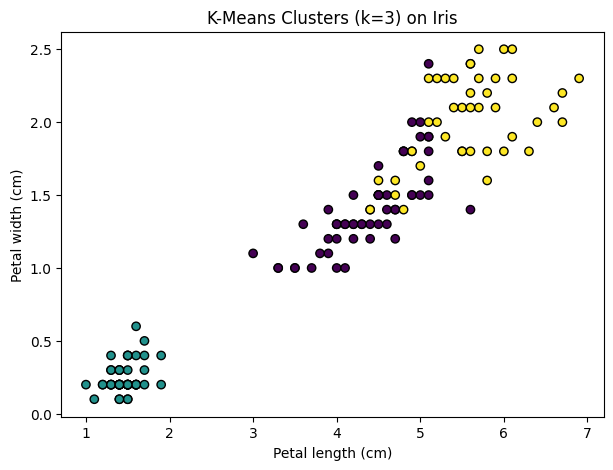

In [ ]:
plt.scatter(X_km['petal length (cm)'], X_km['petal width (cm)'], c=clusters, cmap='viridis', edgecolor='k')
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('K-Means Clusters (k=3) on Iris')
plt.show()

**Interpretation:** The elbow plot shows diminishing returns in inertia past k=3, matching the true number of species. Silhouette score measures how well-separated the clusters are (closer to 1 is better). The crosstab shows clusters align closely with the real species — even though K-Means never saw the labels.

## Summary

| Algorithm | Type | Dataset | Key Metric |
|---|---|---|---|
| Linear Regression | Regression | Diabetes | R², RMSE |
| Logistic Regression | Classification | Breast Cancer | Accuracy, F1 |
| Decision Tree | Classification | Breast Cancer | Accuracy, F1, feature importance |
| Random Forest | Classification (ensemble) | Breast Cancer | Accuracy, F1 (outperforms single tree) |
| K-Means | Clustering (unsupervised) | Iris | Silhouette score |

**Takeaways:**
- Scale features for distance/gradient-based models (Linear/Logistic Regression, K-Means); trees don't need it.
- Ensembles (Random Forest) trade some interpretability for better generalization than a single Decision Tree.
- Classification needs precision/recall/F1, not just accuracy, especially with imbalanced or high-stakes classes.
- Clustering quality is judged internally (silhouette, inertia) since there are no labels to check against during training.